In [ ]:
import torch
import numpy as np
import pandas as pd
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from sklearn.metrics import classification_report, accuracy_score, f1_score
from torch.nn.functional import softmax, sigmoid

In [ ]:
sentiment_model_name = "cardiffnlp/twitter-roberta-base-sentiment"
emotion_model_name = "cardiffnlp/twitter-roberta-large-emotion-latest"

In [ ]:
sentiment_tokenizer = AutoTokenizer.from_pretrained(sentiment_model_name)
emotion_tokenizer = AutoTokenizer.from_pretrained(emotion_model_name)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/747 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/150 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/280 [00:00<?, ?B/s]

In [ ]:
sentiment_model = AutoModelForSequenceClassification.from_pretrained(sentiment_model_name)
emotion_model = AutoModelForSequenceClassification.from_pretrained(emotion_model_name)

pytorch_model.bin:   0%|          | 0.00/499M [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.42G [00:00<?, ?B/s]

In [ ]:
sentiment_model.eval()
emotion_model.eval()

RobertaForSequenceClassification(
  (roberta): RobertaModel(
    (embeddings): RobertaEmbeddings(
      (word_embeddings): Embedding(50265, 1024, padding_idx=1)
      (position_embeddings): Embedding(514, 1024, padding_idx=1)
      (token_type_embeddings): Embedding(1, 1024)
      (LayerNorm): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): RobertaEncoder(
      (layer): ModuleList(
        (0-23): 24 x RobertaLayer(
          (attention): RobertaAttention(
            (self): RobertaSdpaSelfAttention(
              (query): Linear(in_features=1024, out_features=1024, bias=True)
              (key): Linear(in_features=1024, out_features=1024, bias=True)
              (value): Linear(in_features=1024, out_features=1024, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): RobertaSelfOutput(
              (dense): Linear(in_features=1024, out_features=1024, bias=Tru

In [ ]:
emotion_labels = [
    "anger", "anticipation", "disgust", "fear", "joy",
    "love", "optimism", "pessimism", "sadness", "surprise", "trust"
]

#sentiment_labels = ["negative", "neutral", "positive"]


In [ ]:
def predict_sentiment(text):
    enc = sentiment_tokenizer(text, return_tensors="pt", truncation=True)
    with torch.no_grad():
        logits = sentiment_model(**enc).logits
    return softmax(logits, dim=-1).numpy()[0]  # shape = (3,)

In [ ]:
def predict_emotions(text):
    enc = emotion_tokenizer(text, return_tensors="pt", truncation=True)
    with torch.no_grad():
        logits = emotion_model(**enc).logits
    return sigmoid(logits).numpy()[0]  # shape = (11,)

In [ ]:
df = pd.read_excel("data_messages.xlsx")
messages = df[df.columns[0]].astype(str).tolist()
#messages = messages[:100]

# Sentiment labels: numeric 0/1/2
df = pd.read_excel("data_sentiment.xlsx")
sentiment_true = df[df.columns[0]].astype(str).tolist()
#sentiment_true = sentiment_true[:100]

# Emotion labels: in multi-hot
emotion_df = pd.read_excel("data_emotion.xlsx")

# CASE A: Already multi-hot with 11 columns

if set(emotion_df.columns) == set(emotion_labels):
    emotion_true = emotion_df[emotion_labels].values

emotion_true = emotion_df.values
#emotion_true = emotion_true[:100]
print(messages[:5])
print(len(messages))
print(emotion_true[:5])
print(len(emotion_true))
print(sentiment_true[:5])
print(len(sentiment_true))

['to war ironmouseRAID ironmouseRAID ironmouseRAID ironmouseRAID ironmouseRAID ironmouseRAID ironmouseRAID ironmouseRAID ironmouseRAID', '4k sayuwuLul', 'PoroSad oh NYOO NOT ANXIETYYY', 'OH NICE hasL hasL hasL hasL hasL hasL', 'pokiWaiting pokiWaiting pokiO pokiWaiting pokiPOP slayy']
368
[[0 1 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 1 0 0 0 0 0 0]
 [0 0 0 1 0 0 0 0 1 0 0]
 [0 0 0 0 1 1 0 0 0 0 1]
 [0 1 0 0 1 1 0 0 0 0 0]]
368
['2', '2', '0', '2', '2']
368


In [ ]:
emotion_predictions = []
sentiment_predictions = []

for text in messages:
    emo = predict_emotions(text)
    sent = predict_sentiment(text)

    emotion_predictions.append(emo)
    sentiment_predictions.append(np.argmax(sent))

emotion_predictions = np.array(emotion_predictions)
sentiment_predictions = np.array(sentiment_predictions)

thresholds = [0.2]
emotion_binary = (emotion_predictions >= thresholds).astype(int)

Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.


In [ ]:
df_pred = pd.DataFrame({
    "text": messages,                          # your twitch messages
    "sentiment_true": sentiment_true,
    "sentiment_pred": sentiment_predictions
})

# Add emotion labels (multi-label)
for i, label in enumerate(emotion_labels):
    df_pred[f"true_{label}"] = emotion_true[:, i]
    df_pred[f"pred_{label}"] = emotion_binary[:, i]  # or emotion_predictions for probs

df_pred.to_csv("predictions.csv", index=False)
print("Saved predictions to predictions.csv")

Saved predictions to predictions.csv


In [ ]:
!pip install numpy
!pip install matplotlib
!pip install itertools

ERROR: Could not find a version that satisfies the requirement itertools (from versions: none)
ERROR: No matching distribution found for itertools


In [ ]:
!python setup.py install

running install
/usr/local/lib/python3.12/dist-packages/setuptools/_distutils/cmd.py:66: SetuptoolsDeprecationWarning: setup.py install is deprecated.
!!

        ********************************************************************************
        Please avoid running ``setup.py`` directly.
        Instead, use pypa/build, pypa/installer or other
        standards-based tools.

        See https://blog.ganssle.io/articles/2021/10/setup-py-deprecated.html for details.
        ********************************************************************************

!!
  self.initialize_options()
/usr/local/lib/python3.12/dist-packages/setuptools/_distutils/cmd.py:66: EasyInstallDeprecationWarning: easy_install command is deprecated.
!!

        ********************************************************************************
        Please avoid running ``setup.py`` and ``easy_install``.
        Instead, use pypa/build, pypa/installer or other
        standards-based tools.

        See https

In [ ]:
import mlcm

SyntaxError: Missing parentheses in call to 'print'. Did you mean print(...)? (conf_matrx.py, line 25)

In [ ]:
print("\n=== Sentiment Model Evaluation (0,1,2) ===")
print("Accuracy:", accuracy_score(sentiment_true, sentiment_predictions))
print("\nSentiment Classification Report:")
# Convert sentiment_true to a numpy array of integers for consistency with sentiment_predictions
sentiment_true_int = np.array(sentiment_true).astype(int)
print(classification_report(sentiment_true_int, sentiment_predictions, target_names=["negative", "neutral", "positive"]))


=== Sentiment Model Evaluation (0,1,2) ===
Accuracy: 0.0

Sentiment Classification Report:
              precision    recall  f1-score   support

    negative       0.48      0.47      0.47        66
     neutral       0.39      0.72      0.51       127
    positive       0.69      0.26      0.38       175

    accuracy                           0.46       368
   macro avg       0.52      0.49      0.45       368
weighted avg       0.55      0.46      0.44       368



In [ ]:
print("=== Emotion Model Evaluation (11 labels) ===")
print("Micro F1:", f1_score(emotion_true, emotion_binary, average="micro"))
print("Macro F1:", f1_score(emotion_true, emotion_binary, average="macro"))
print("\nEmotion Classification Report:")
print(classification_report(emotion_true, emotion_binary, target_names=emotion_labels))

=== Emotion Model Evaluation (11 labels) ===
Micro F1: 0.5026737967914439
Macro F1: 0.41111348226113675

Emotion Classification Report:
              precision    recall  f1-score   support

       anger       0.31      0.65      0.42        26
anticipation       0.42      0.62      0.50        71
     disgust       0.48      0.56      0.52        55
        fear       0.38      0.33      0.36        15
         joy       0.72      0.80      0.75       222
        love       0.55      0.47      0.50        73
    optimism       0.19      0.73      0.30        37
   pessimism       0.22      0.13      0.16        38
     sadness       0.41      0.62      0.49        29
    surprise       0.71      0.33      0.45        45
       trust       0.50      0.03      0.06       100

   micro avg       0.48      0.53      0.50       711
   macro avg       0.44      0.48      0.41       711
weighted avg       0.53      0.53      0.48       711
 samples avg       0.46      0.56      0.48       71

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
# ROC-AUC AND PR-AUC (PER LABEL)
print("\nROC-AUC per emotion:")
for i, label in enumerate(emotion_labels):
    try:
        auc = roc_auc_score(emotion_true[:, i], emotion_predictions[:, i])
        print(f"{label:14s}: {auc:.3f}")
    except ValueError:
        print(f"{label:14s}: Not enough positive or negative samples")
print("\nPR-AUC per emotion:")
for i, label in enumerate(emotion_labels):
    try:
        ap = average_precision_score(emotion_true[:, i], emotion_predictions[:, i])
        print(f"{label:14s}: {ap:.3f}")
    except ValueError:
        print(f"{label:14s}: Not enough samples")


ROC-AUC per emotion:
anger         : 0.824
anticipation  : 0.748
disgust       : 0.847
fear          : 0.875
joy           : 0.730
love          : 0.749
optimism      : 0.758
pessimism     : 0.668
sadness       : 0.882
surprise      : 0.746
trust         : 0.568

PR-AUC per emotion:
anger         : 0.418
anticipation  : 0.461
disgust       : 0.491
fear          : 0.351
joy           : 0.799
love          : 0.552
optimism      : 0.295
pessimism     : 0.203
sadness       : 0.656
surprise      : 0.518
trust         : 0.359


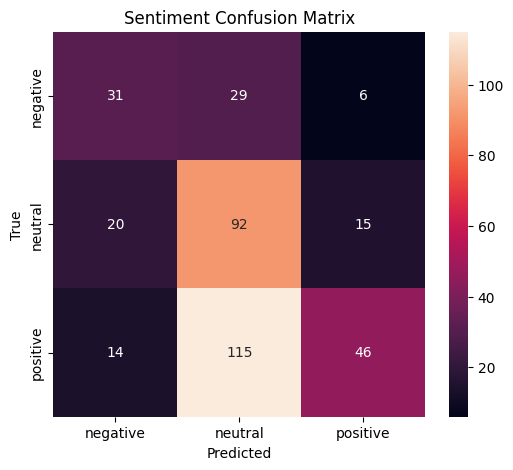

In [ ]:
cm_sent = confusion_matrix(sentiment_true_int, sentiment_predictions)

plt.figure(figsize=(6,5))
sns.heatmap(cm_sent, annot=True, fmt="d",
            xticklabels=["negative","neutral","positive"],
            yticklabels=["negative","neutral","positive"])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Sentiment Confusion Matrix")
plt.show()

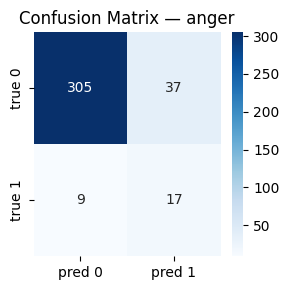

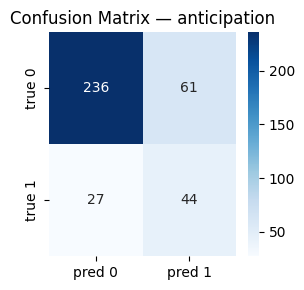

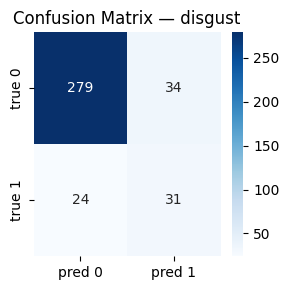

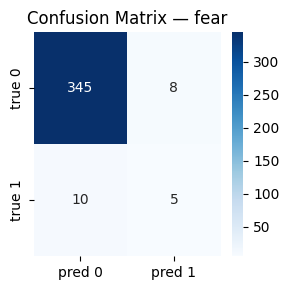

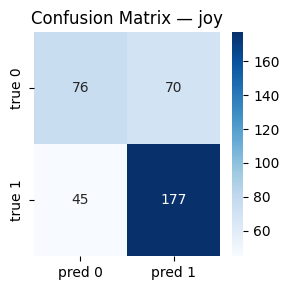

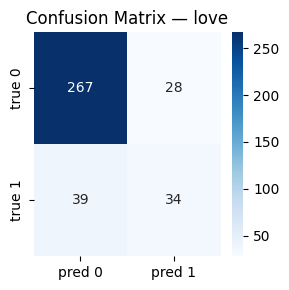

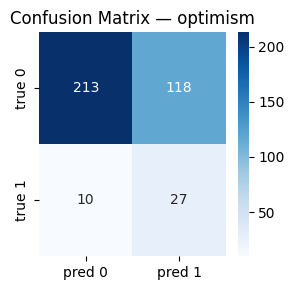

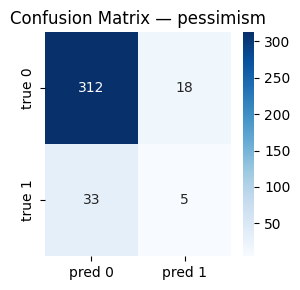

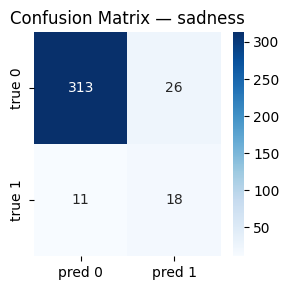

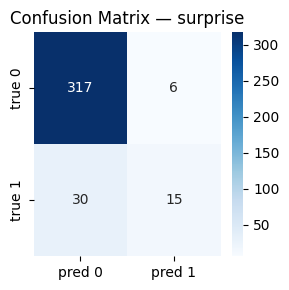

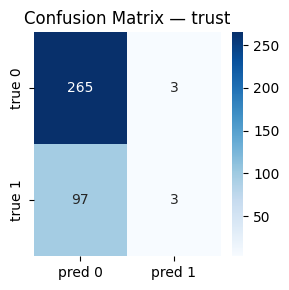

In [ ]:
# PER-LABEL 2x2 CONFUSION MATRICES
for i, label in enumerate(emotion_labels):
    cm = confusion_matrix(emotion_true[:, i], emotion_binary[:, i])
    plt.figure(figsize=(3,3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=["pred 0","pred 1"],
                yticklabels=["true 0","true 1"])
    plt.title(f"Confusion Matrix — {label}")
    plt.tight_layout()
    plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    classification_report,
    accuracy_score,
    f1_score,
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
)

In [ ]:
# Global threshold tuning
def tune_global_threshold(pred_probs, y_true):
    best_t = 0.5
    best_f1 = 0

    for t in np.arange(0.05, 0.55, 0.05):
        preds = (pred_probs >= t).astype(int)
        f1 = f1_score(y_true, preds, average="micro")
        if f1 > best_f1:
            best_f1 = f1
            best_t = t
    return best_t, best_f1

global_t, global_f1 = tune_global_threshold(emotion_predictions, emotion_true)
print(f"\nBest global threshold = {global_t:.2f}    Micro-F1 = {global_f1:.4f}")


Best global threshold = 0.20    Micro-F1 = 0.5027


In [ ]:
# Per-label threshold tuning
def tune_per_label_thresholds(pred_probs, y_true):
    best_thresh = []
    for i in range(pred_probs.shape[1]):
        best_t = 0.5
        best_f1 = 0
        for t in np.arange(0.05, 0.55, 0.05):
            preds = (pred_probs[:, i] >= t).astype(int)
            f1 = f1_score(y_true[:, i], preds, average="binary")
            if f1 > best_f1:
                best_f1 = f1
                best_t = t
        best_thresh.append(best_t)
    return np.array(best_thresh)

per_label_thresholds = tune_per_label_thresholds(emotion_predictions, emotion_true)
print("\nPer-label optimal thresholds:")
for lbl, t in zip(emotion_labels, per_label_thresholds):
    print(f"{lbl:14s}: {t:.2f}")


Per-label optimal thresholds:
anger         : 0.40
anticipation  : 0.20
disgust       : 0.30
fear          : 0.20
joy           : 0.05
love          : 0.10
optimism      : 0.50
pessimism     : 0.05
sadness       : 0.50
surprise      : 0.10
trust         : 0.05


In [ ]:
# Choose which thresholds to use (recommended: per-label)
thresholds = per_label_thresholds

In [ ]:
emotion_predictions = []
sentiment_predictions = []

for text in messages:
    emo = predict_emotions(text)
    sent = predict_sentiment(text)

    emotion_predictions.append(emo)
    sentiment_predictions.append(np.argmax(sent))

emotion_predictions = np.array(emotion_predictions)
sentiment_predictions = np.array(sentiment_predictions)

emotion_binary = (emotion_predictions >= thresholds).astype(int)

In [ ]:
# MULTI-LABEL EVALUATION METRICS
print("\n==================== MULTI-LABEL EMOTION EVALUATION ====================\n")
print("Micro-F1:", f1_score(emotion_true, emotion_binary, average="micro"))
print("Macro-F1:", f1_score(emotion_true, emotion_binary, average="macro"))

# Detailed per-label report
print("\nPer-label classification report:")
print(classification_report(emotion_true, emotion_binary, target_names=emotion_labels))



==================== MULTI-LABEL EMOTION EVALUATION ====================

Micro-F1: 0.5596446700507615
Macro-F1: 0.4754468599858329

Per-label classification report:
              precision    recall  f1-score   support

       anger       0.41      0.62      0.49        26
anticipation       0.42      0.62      0.50        71
     disgust       0.53      0.51      0.52        55
        fear       0.38      0.33      0.36        15
         joy       0.68      0.94      0.79       222
        love       0.49      0.59      0.54        73
    optimism       0.25      0.51      0.34        37
   pessimism       0.17      0.21      0.19        38
     sadness       0.72      0.62      0.67        29
    surprise       0.50      0.51      0.51        45
       trust       0.42      0.28      0.34       100

   micro avg       0.51      0.62      0.56       711
   macro avg       0.45      0.52      0.48       711
weighted avg       0.51      0.62      0.55       711
 samples avg       0.

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


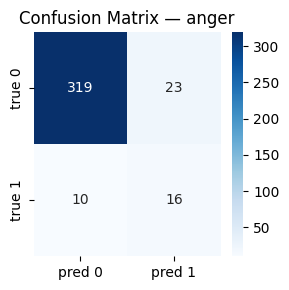

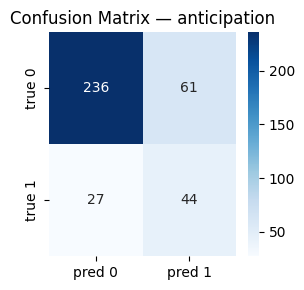

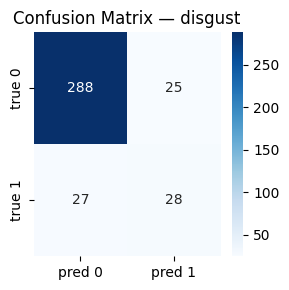

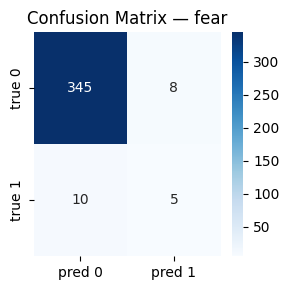

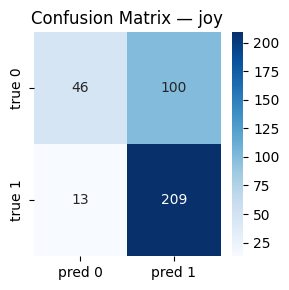

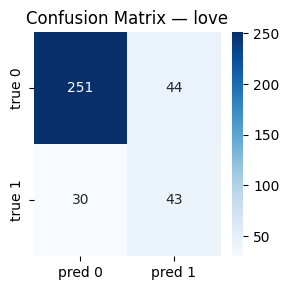

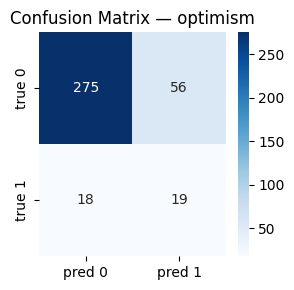

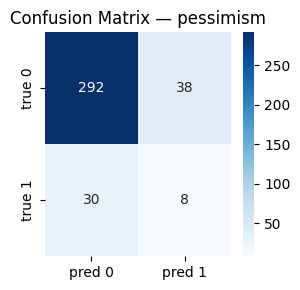

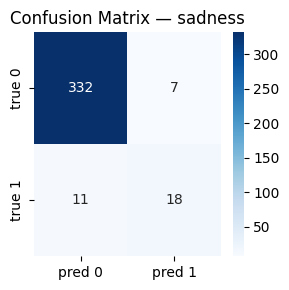

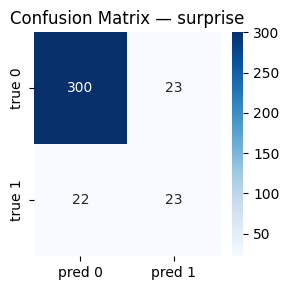

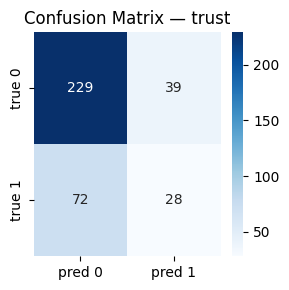

In [ ]:
# PER-LABEL 2x2 CONFUSION MATRICES
for i, label in enumerate(emotion_labels):
    cm = confusion_matrix(emotion_true[:, i], emotion_binary[:, i])
    plt.figure(figsize=(3,3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=["pred 0","pred 1"],
                yticklabels=["true 0","true 1"])
    plt.title(f"Confusion Matrix — {label}")
    plt.tight_layout()
    plt.show()


In [ ]:
# ROC-AUC AND PR-AUC (PER LABEL)
print("\nROC-AUC per emotion:")
for i, label in enumerate(emotion_labels):
    try:
        auc = roc_auc_score(emotion_true[:, i], emotion_predictions[:, i])
        print(f"{label:14s}: {auc:.3f}")
    except ValueError:
        print(f"{label:14s}: Not enough positive or negative samples")
print("\nPR-AUC per emotion:")
for i, label in enumerate(emotion_labels):
    try:
        ap = average_precision_score(emotion_true[:, i], emotion_predictions[:, i])
        print(f"{label:14s}: {ap:.3f}")
    except ValueError:
        print(f"{label:14s}: Not enough samples")



ROC-AUC per emotion:
anger         : 0.824
anticipation  : 0.748
disgust       : 0.847
fear          : 0.875
joy           : 0.730
love          : 0.749
optimism      : 0.758
pessimism     : 0.668
sadness       : 0.882
surprise      : 0.746
trust         : 0.568

PR-AUC per emotion:
anger         : 0.418
anticipation  : 0.461
disgust       : 0.491
fear          : 0.351
joy           : 0.799
love          : 0.552
optimism      : 0.295
pessimism     : 0.203
sadness       : 0.656
surprise      : 0.518
trust         : 0.359


In [ ]:
print("=== Emotion Model Evaluation (11 labels) ===")
print("Micro F1:", f1_score(emotion_true, emotion_binary, average="micro"))
print("Macro F1:", f1_score(emotion_true, emotion_binary, average="macro"))
print("\nEmotion Classification Report:")
print(classification_report(emotion_true, emotion_binary, target_names=emotion_labels))

=== Emotion Model Evaluation (11 labels) ===
Micro F1: 0.5596446700507615
Macro F1: 0.4754468599858329

Emotion Classification Report:
              precision    recall  f1-score   support

       anger       0.41      0.62      0.49        26
anticipation       0.42      0.62      0.50        71
     disgust       0.53      0.51      0.52        55
        fear       0.38      0.33      0.36        15
         joy       0.68      0.94      0.79       222
        love       0.49      0.59      0.54        73
    optimism       0.25      0.51      0.34        37
   pessimism       0.17      0.21      0.19        38
     sadness       0.72      0.62      0.67        29
    surprise       0.50      0.51      0.51        45
       trust       0.42      0.28      0.34       100

   micro avg       0.51      0.62      0.56       711
   macro avg       0.45      0.52      0.48       711
weighted avg       0.51      0.62      0.55       711
 samples avg       0.55      0.65      0.55       711

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
print("\n=== Sentiment Model Evaluation (0,1,2) ===")
print("Accuracy:", accuracy_score(sentiment_true, sentiment_predictions))
print("\nSentiment Classification Report:")
# Convert sentiment_true to a numpy array of integers for consistency with sentiment_predictions
sentiment_true_int = np.array(sentiment_true).astype(int)
print(classification_report(sentiment_true_int, sentiment_predictions, target_names=["negative", "neutral", "positive"]))


=== Sentiment Model Evaluation (0,1,2) ===
Accuracy: 0.0

Sentiment Classification Report:
              precision    recall  f1-score   support

    negative       0.48      0.47      0.47        66
     neutral       0.39      0.72      0.51       127
    positive       0.69      0.26      0.38       175

    accuracy                           0.46       368
   macro avg       0.52      0.49      0.45       368
weighted avg       0.55      0.46      0.44       368



In [ ]:
print("Average predicted probabilities per label:")
print(emotion_predictions.mean(axis=0))

print("\nPercent of messages where probability >= 0.5:")
print((emotion_predictions >= 0.5).mean(axis=0))

Average predicted probabilities per label:
[0.11771959 0.19339386 0.12841772 0.04110543 0.5521618  0.12145425
 0.24666215 0.04144396 0.10996646 0.06157242 0.03329706]

Percent of messages where probability >= 0.5:
[0.08423913 0.09782609 0.10326087 0.02717391 0.54347826 0.0951087
 0.20380435 0.01902174 0.06793478 0.02717391 0.        ]


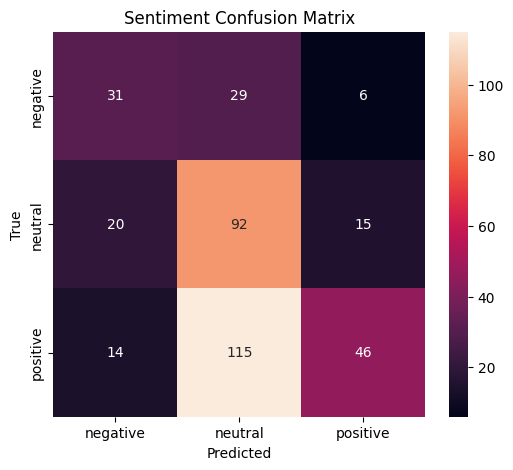

In [ ]:
cm_sent = confusion_matrix(sentiment_true_int, sentiment_predictions)

plt.figure(figsize=(6,5))
sns.heatmap(cm_sent, annot=True, fmt="d",
            xticklabels=["negative","neutral","positive"],
            yticklabels=["negative","neutral","positive"])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Sentiment Confusion Matrix")
plt.show()

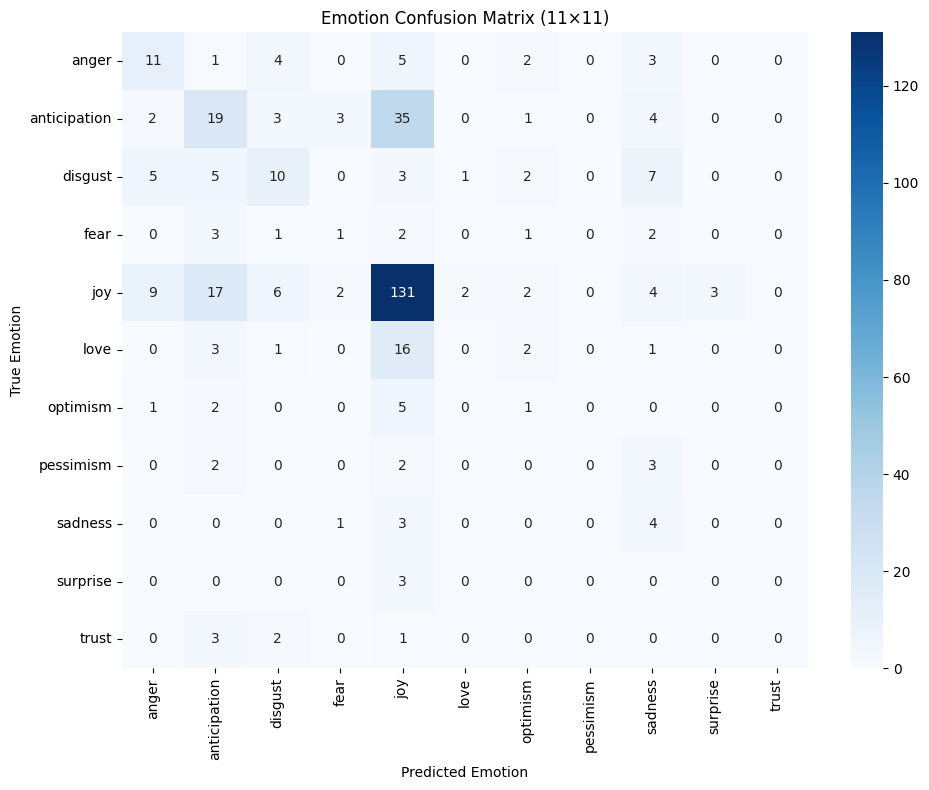

In [ ]:
# true: multi-hot → convert to index
true_idx = np.argmax(emotion_true, axis=1)

# predicted: probability → convert to index
pred_idx = np.argmax(emotion_predictions, axis=1)

# --------------------------------------------------
# Build 11×11 confusion matrix
# --------------------------------------------------

cm = confusion_matrix(true_idx, pred_idx, labels=range(11))

plt.figure(figsize=(10, 8))
sns.heatmap(cm,
            annot=True,
            fmt="d",
            xticklabels=emotion_labels,
            yticklabels=emotion_labels,
            cmap="Blues")

plt.xlabel("Predicted Emotion")
plt.ylabel("True Emotion")
plt.title("Emotion Confusion Matrix (11×11)")
plt.tight_layout()
plt.show()

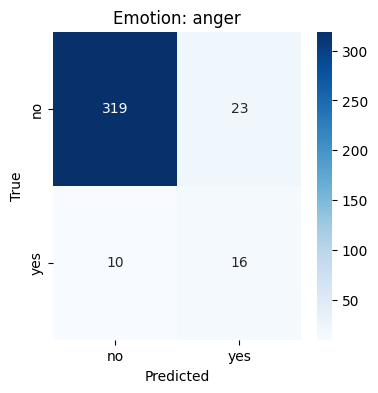

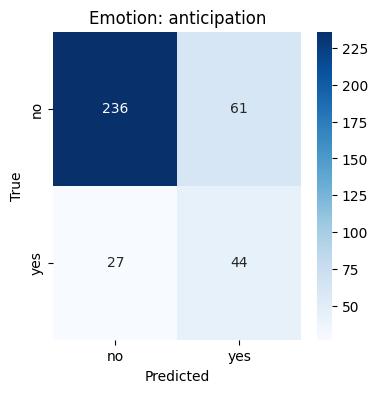

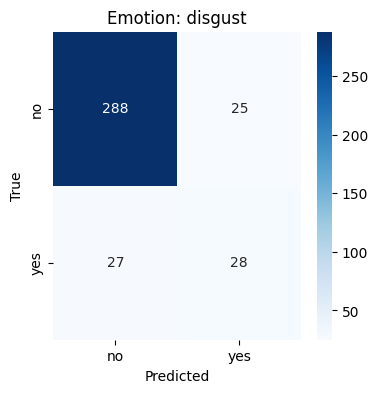

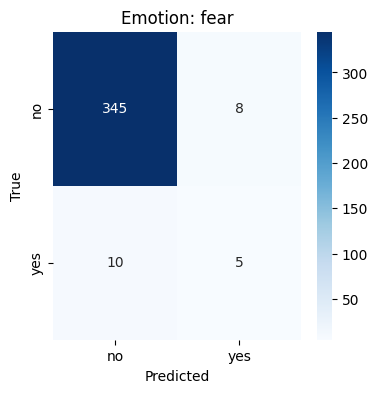

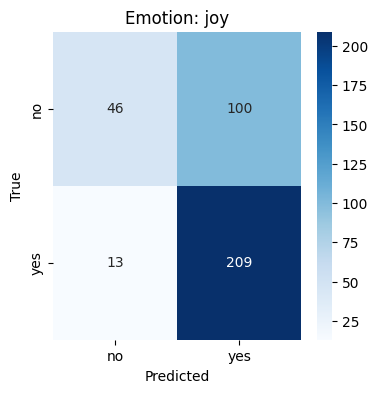

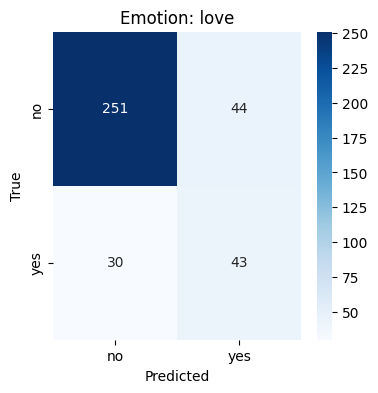

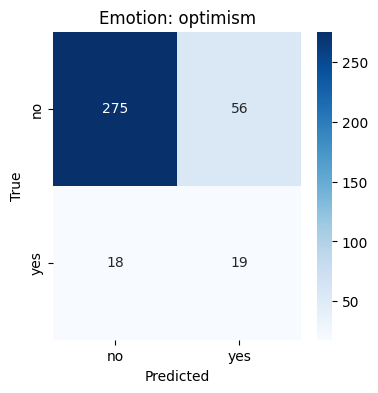

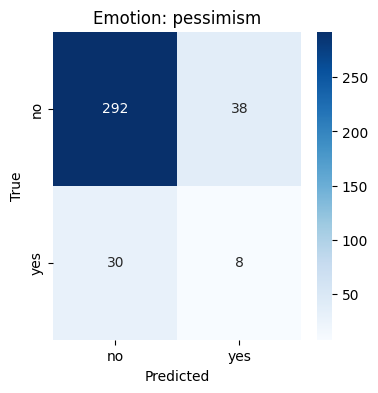

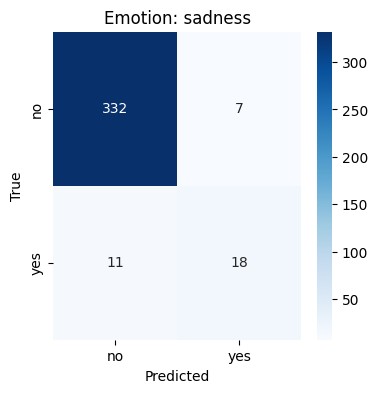

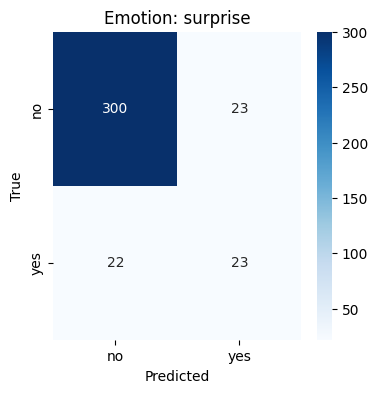

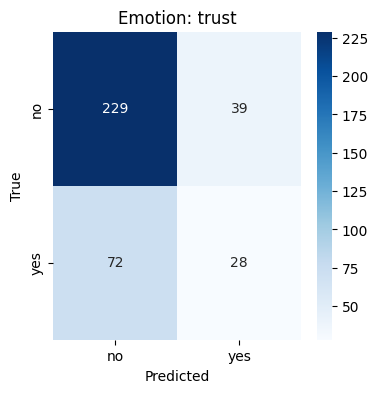

In [ ]:
for i, label in enumerate(emotion_labels):
    y_true = emotion_true[:, i]
    y_pred = emotion_binary[:, i]

    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(4,4))
    sns.heatmap(cm, annot=True, fmt="d",
                xticklabels=["no", "yes"],
                yticklabels=["no", "yes"],
                cmap="Blues")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title(f"Emotion: {label}")
    plt.show()